In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [84]:

import pandas as pd
import os

data_folder = "../data"
all_dfs = []

valid_countries = ["ethiopia", "kenya", "nigeria", "sudan", "tanzania"]
for file in os.listdir(data_folder):
    if file.endswith(".csv"):
        country = file.replace(".csv", "").lower()

        if country not in valid_countries:
            continue

        file_path = os.path.join(data_folder, file)

        country = file.replace(".csv", "")

        df = pd.read_csv(file_path)
        df["COUNTRY"] = country

        all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)
final_df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,ethiopia


Extreme Climate Event Definitions
- Extreme Heat: Temperature (T2M) > 35°C
- Drought: Precipitation (PRECTOTCORR) < 1 mm/day

These thresholds are used to quantify climate stress frequency across countries.

In [85]:
HEAT_THRESHOLD = 35
DROUGHT_THRESHOLD = 1

extreme_stats = []

for country, df_country in final_df.groupby("COUNTRY"):
    heat_days = (df_country["T2M"] > HEAT_THRESHOLD).sum()
    drought_days = (df_country["PRECTOTCORR"] < DROUGHT_THRESHOLD).sum()
    total_days = len(df_country)

    extreme_stats.append({
        "Country": country,
        "Extreme_Heat_Days": heat_days,
        "Drought_Days": drought_days,
        "Heat_Frequency_%": (heat_days / total_days) * 100,
        "Drought_Frequency_%": (drought_days / total_days) * 100
    })

extreme_df = pd.DataFrame(extreme_stats)
extreme_df

,Country,Extreme_Heat_Days,Drought_Days,Heat_Frequency_%,Drought_Frequency_%
0,ethiopia,0,2161,0.000000,52.604674
1,kenya,0,2831,0.000000,68.914314
2,nigeria,0,1595,0.000000,38.826680
3,sudan,325,3696,7.911392,89.970789
4,tanzania,0,2303,0.000000,56.061344


DATA CLEANING DECISIONS
- Replaced -999 values with NaN as they represent missing satellite observations
- Converted YEAR and DOY into a proper datetime format for time-series analysis
- Standardized country labels for consistency across datasets

Converting YEAR + DOY to Datetime

In [86]:
final_df["YEAR"] = pd.to_numeric(final_df["YEAR"], errors="coerce")
final_df["DOY"] = pd.to_numeric(final_df["DOY"], errors="coerce")

final_df["date"] = pd.to_datetime(
    final_df["YEAR"] * 1000 + final_df["DOY"],
    format="%Y%j",
    errors="coerce"
)
final_df["Month"] = final_df["date"].dt.month

Verification

In [87]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,tanzania


Extracting month

In [88]:
final_df["Month"] = final_df["date"].dt.month

Replacing -999 with Nan

Sentinel values (-999) were replaced with NaN to correctly represent missing data and allow proper statistical handling.

In [89]:
import numpy as np

df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,COUNTRY
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,tanzania
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.63,30.65,25.66,4.99,2.96,77.48,1.57,2.40,100.73,17.72,tanzania
4104,2026,87,27.51,31.23,24.84,6.39,1.65,77.72,1.36,1.79,100.61,17.59,tanzania
4105,2026,88,27.74,31.21,25.33,5.88,1.28,77.35,1.53,2.01,100.42,17.81,tanzania
4106,2026,89,27.83,31.29,25.31,5.98,0.92,76.50,1.64,2.15,100.43,17.72,tanzania


Removing duplicates

Duplicate rows were identified and removed to prevent bias and double-counting in the analysis.

In [90]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


Summary Statistics

In [91]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000


Missing values Analysis

Missing values were handled using forward fill, which is appropriate for time-series data where observations are temporally dependent.

In [92]:
missing = df.isna().sum()
percent_missing = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing": missing,
    "Percent": percent_missing
})

missing_df

,Missing,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


OUTLIER DETECTION

Z-scores were computed for key climate variables. Values with |Z| > 3 were flagged as potential outliers. These may represent extreme weather events or measurement anomalies.

Z-score

In [93]:
from scipy import stats
import numpy as np

cols = [col for col in ["T2M", "PRECTOTCORR", "RH2M"] if col in df.columns]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3)

print("Outliers per column:\n", outliers.sum())

Outliers per column:
 84


Handling outliers

Outliers were detected using Z-score and removed to reduce the influence of extreme values on analysis results.

In [94]:
df = df[(z_scores < 3).all(axis=1)]

Handling missing values

In [95]:
df = df.ffill()

Exporting cleaned data

In [96]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

Monthly Temperature

VULNERABILITY SCORING METHOD

A composite vulnerability score was calculated using:
- Temperature (T2M)
- Precipitation (PRECTOTCORR)
- Humidity (RH2M)

Weights were assigned to reflect their relative contribution to climate stress.

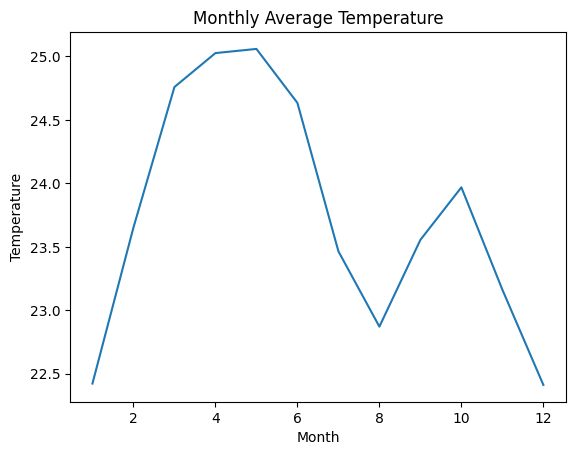

In [97]:
monthly_temp = final_df.groupby("Month")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

Monthly Precipitation

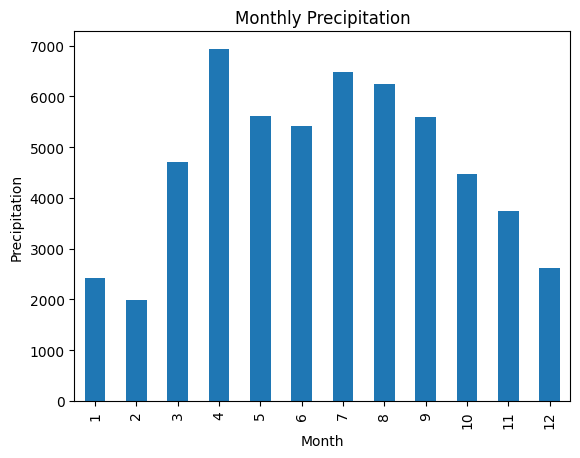

In [98]:
monthly_precip = final_df.groupby("Month")["PRECTOTCORR"].sum()

monthly_precip.plot(kind="bar")
plt.title("Monthly Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

Correlation Analysis

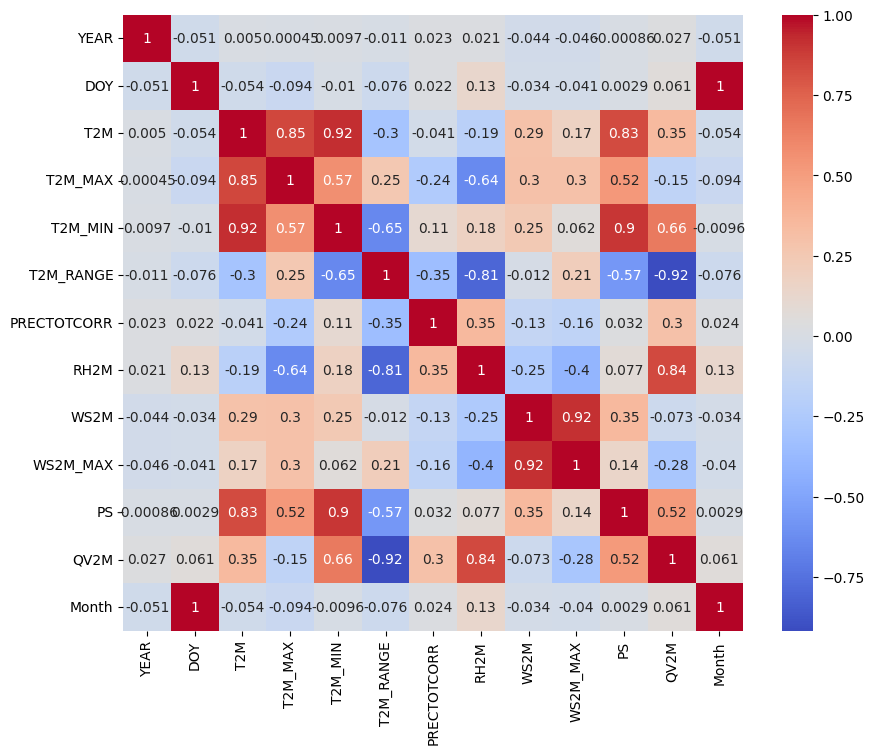

In [99]:
import seaborn as sns 

corr = final_df.corr(numeric_only=True) 

plt.figure(figsize=(10,8)) 
sns.heatmap(corr, annot=True, cmap="coolwarm") 
plt.show()

Scatter plots

['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'COUNTRY']


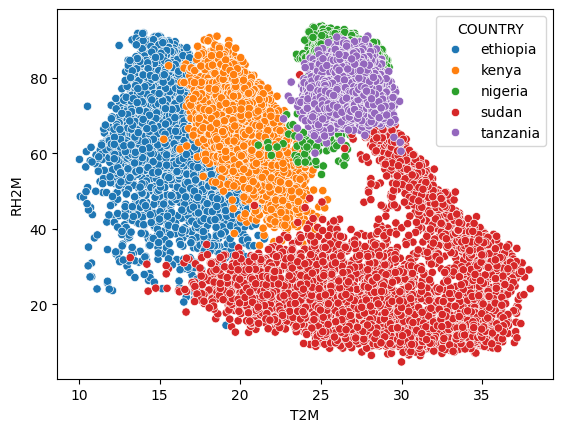

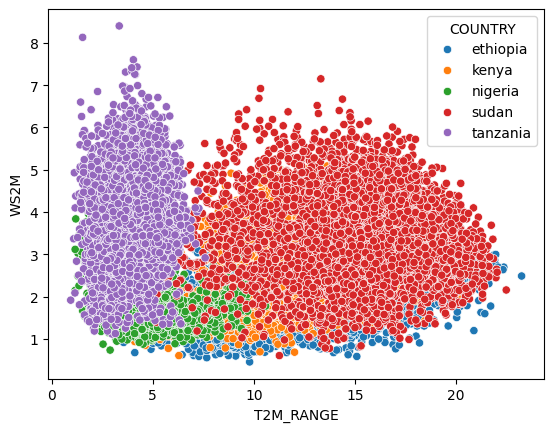

In [ ]:
sns.scatterplot(x="T2M", y="RH2M", hue="COUNTRY", data=final_df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", hue="COUNTRY", data=final_df)
plt.show()

Histogram

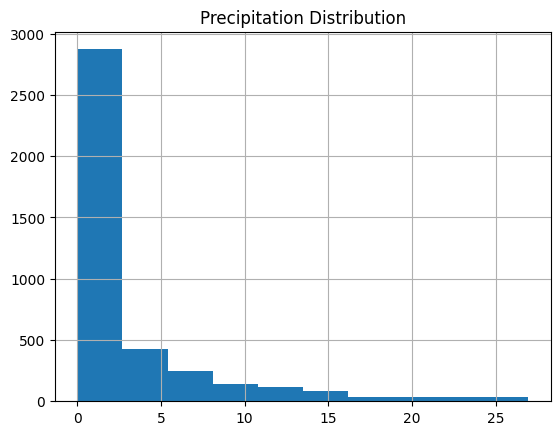

In [101]:
df["PRECTOTCORR"].hist()
plt.title("Precipitation Distribution")
plt.show()

Bubble Chart

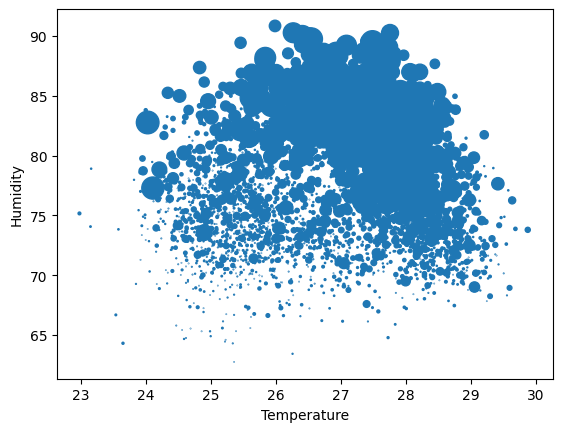

In [102]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()